# Klasifikasi Lahan Sawah dan Non-Sawah menggunakan Sentinel-2A dan Random Forest

Pemanfaatan citra Sentinel-2A dapat digunakan untuk mengidentifikasi tutupan lahan berdasarkan karakteristik spektralnya, termasuk membedakan wilayah sawah dan non-sawah. Penelitian ini menggunakan 100 sampel, terdiri dari 50 sampel sawah dan 50 sampel non-sawah. Data Sentinel-2A Level-2A menggunakan band B02, B03, B04, B08, dan B11, serta fitur tambahan berupa NDVI dan NDWI. Seluruh fitur digunakan untuk membangun model klasifikasi Random Forest, kemudian hasilnya divisualisasikan menggunakan QGIS.

| Data | Keterangan |
|---|---|
| Sentinel-2A | Level-2A |
| B02 | Blue |
| B03 | Green |
| B04 | Red |
| B08 | Near Infrared (NIR) |
| B11 | Short Wave Infrared (SWIR) |
| Sampel Sawah | 50 sampel |
| Sampel Non-Sawah | 50 sampel |


## 1. Menyiapkan dan Menggabungkan Data Sampel

Membaca data spasial sampel sawah dan non-sawah dalam format Shapefile (.shp). Masing-masing data kemudian diberi label agar dapat digunakan sebagai data klasifikasi.

Data sawah diberi label sawah, sedangkan data non-sawah diberi label non_sawah. Setelah itu kedua data digabungkan menjadi satu GeoDataFrame.

In [3]:
import geopandas as gpd
import pandas as pd

sawah = gpd.read_file("materi/Sampel Sawah/input.shp")
nonsawah = gpd.read_file("materi/Sampel Non-Sawah/input.shp")

sawah["label"] = "sawah"
nonsawah["label"] = "non_sawah"

sampel = gpd.GeoDataFrame(
    pd.concat([sawah, nonsawah], ignore_index=True),
    crs=sawah.crs
)

print("Jumlah sampel:", len(sampel))
print(sampel["label"].value_counts())

Jumlah sampel: 100
label
sawah        50
non_sawah    50
Name: count, dtype: int64


## 2. Menentukan Batas Wilayah Sampel

Mengubah sistem koordinat sampel menjadi EPSG:4326, yaitu sistem koordinat geografis berbasis lintang dan bujur.

Kemudian total_bounds digunakan untuk mendapatkan batas wilayah yang mencakup seluruh sampel.

Menunjukkan batas geografis wilayah penelitian:

- West = 112.1881514
- East = 112.1955727
- South = -7.2227551
- North = -7.2025308

Batas tersebut nantinya digunakan untuk mengambil citra Sentinel-2A pada wilayah yang sesuai dengan lokasi sampel

In [4]:
sampel_wgs84 = sampel.to_crs("EPSG:4326")

minx, miny, maxx, maxy = sampel_wgs84.total_bounds

spatial_extent = {
    "west": float(minx),
    "south": float(miny),
    "east": float(maxx),
    "north": float(maxy)
}

print(spatial_extent)

{'west': 112.1881514, 'south': -7.2227551, 'east': 112.1955727, 'north': -7.2025308}


## 3. Menghubungkan ke OpenEO Copernicus

membuat koneksi ke OpenEO Copernicus Data Space. Platform ini digunakan untuk mengakses data penginderaan jauh, termasuk citra Sentinel-2.

authenticate_oidc() digunakan untuk melakukan autentikasi agar notebook dapat mengakses data.

In [5]:
import openeo

conn = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
)

conn.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## 4. Mengambil Data Sentinel-2A
Mmengambil koleksi data Sentinel-2 Level-2A berdasarkan:

- Wilayah penelitian
- Periode waktu 31 Agustus 2025 sampai 31 Agustus 2026
- Band B02, B03, B04, B08, dan B11

Kelima band tersebut digunakan sebagai fitur spektral dalam klasifikasi.

In [6]:
datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[
        "2025-08-31",
        "2026-08-31"
    ],
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11"
    ]
)

print("Datacube berhasil dibuat")

Datacube berhasil dibuat


## 5. Menyimpan Citra Sentinel-2 sebagai TIF

Data Sentinel-2 yang telah diambil kemudian diunduh dan disimpan dalam format GeoTIFF, yang nantinya digunakan untuk mengambil nilai spektral dan melakukan klasifikasi.

In [7]:
output_path = "materi/Sentinel2_kedungpring_sampel.tif"

datacube.download(
    output_path,
    format="GTiff"
)

print("TIF berhasil disimpan:", output_path)

TIF berhasil disimpan: materi/Sentinel2_kedungpring_sampel.tif


In [ ]:
# Memeriksa Informasi Raster

import rasterio

with rasterio.open(output_path) as src:
    print("Jumlah band:", src.count)
    print("Nama band:", src.descriptions)
    print("CRS:", src.crs)
    print("Batas raster:", src.bounds)

Jumlah band: 5
Nama band: ('B02', 'B03', 'B04', 'B08', 'B11')
CRS: EPSG:32749
Batas raster: BoundingBox(left=631170.0, bottom=9201450.0, right=632010.0, top=9203700.0)


In [ ]:
# Memeriksa NoData

import rasterio

tif_path = "materi/Sentinel2_kedungpring_sampel.tif"

src = rasterio.open(tif_path)

print("Band:", src.descriptions)
print("CRS:", src.crs)
print("NoData:", src.nodata)

Band: ('B02', 'B03', 'B04', 'B08', 'B11')
CRS: EPSG:32749
NoData: -32768.0


**Note :** Nilai -32768 merupakan nilai khusus yang digunakan untuk menunjukkan bahwa suatu piksel tidak memiliki data yang valid.

Nilai ini nantinya tidak akan digunakan dalam perhitungan nilai rata-rata band.

## 6. Menyamakan Sistem Koordinat Sampel dan Raster

Sampel dikonversi ke CRS yang sama dengan raster, yaitu EPSG:32749.

Hal ini penting supaya lokasi sampel tepat ketika digunakan untuk mengambil nilai piksel dari citra Sentinel-2.

In [10]:
sampel = sampel.to_crs(src.crs)

print("CRS sampel:", sampel.crs)
print("CRS raster:", src.crs)

CRS sampel: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32749"]]
CRS raster: EPSG:32749


## 7. Mengambil Nilai Band pada Setiap Sampel

Melakukan perulangan terhadap seluruh sampel.

Setiap geometri sampel digunakan untuk mengambil bagian citra Sentinel-2 yang berada di dalam wilayah sampel.

Kemudian nilai piksel dari setiap band dihitung rata-ratanya.

In [13]:
from rasterio.mask import mask
import numpy as np

hasil = []

for idx, row in sampel.iterrows():

    data, transform = mask(
        src,
        [row.geometry],
        crop=True
    )

    nilai = {
        "FID": idx,
        "label": row["label"]
    }

    for i, band_name in enumerate(src.descriptions):

        band = data[i]

        # Hilangkan nilai NoData
        valid = band[
            (band != src.nodata) &
            np.isfinite(band)
        ]

        if len(valid) > 0:
            nilai[band_name] = float(np.mean(valid))
        else:
            nilai[band_name] = np.nan

    hasil.append(nilai)

df = pd.DataFrame(hasil)

## 8. 5 Sampel Sawah dan Non-Sawah

Nilai spektral sampel sawah dan non-sawah memiliki perbedaan. Perbedaan karakteristik spektral inilah yang kemudian dimanfaatkan oleh Random Forest untuk melakukan klasifikasi.

In [14]:
band_cols = ["FID", "label", "B02", "B03", "B04", "B08", "B11"]

hasil_sawah = df[df["label"] == "sawah"].head(5)
hasil_nonsawah = df[df["label"] == "non_sawah"].head(5)

print("===== 5 SAMPEL SAWAH PERTAMA =====")
display(hasil_sawah[band_cols])

print("\n===== 5 SAMPEL NON-SAWAH PERTAMA =====")
display(hasil_nonsawah[band_cols])

===== 5 SAMPEL SAWAH PERTAMA =====


,FID,label,B02,B03,B04,B08,B11
0,0,sawah,1134.250000,1273.125000,1235.875000,1902.125000,1286.187500
1,1,sawah,1099.250000,1250.750000,1172.250000,1928.250000,1269.500000
2,2,sawah,1140.000000,1300.666667,1283.333333,1980.666667,1546.333333
3,3,sawah,1156.888889,1302.000000,1236.888889,2004.222222,1487.555556
4,4,sawah,1179.272727,1310.272727,1228.272727,1989.545455,1288.136364



===== 5 SAMPEL NON-SAWAH PERTAMA =====


,FID,label,B02,B03,B04,B08,B11
50,50,non_sawah,7890.222222,7161.777778,6484.888889,6538.222222,4916.444444
51,51,non_sawah,4601.000000,4872.000000,4908.000000,4565.000000,4317.750000
52,52,non_sawah,3562.000000,3526.666667,3584.000000,3642.666667,3541.000000
53,53,non_sawah,5320.800000,4201.600000,3488.800000,4416.800000,3384.200000
54,54,non_sawah,4952.000000,3776.000000,3071.333333,4157.333333,2774.666667


In [ ]:
# Mengecek Jumlah Data dan Missing Value

print(df["label"].value_counts())

print(df[["B02", "B03", "B04", "B08", "B11"]].isna().sum())

label
sawah        50
non_sawah    50
Name: count, dtype: int64
B02    0
B03    0
B04    0
B08    0
B11    0
dtype: int64


## 9. Menghitung NDVI dan NDWI

NDVI digunakan sebagai fitur tambahan yang menggambarkan karakteristik vegetasi.

NDWI digunakan sebagai fitur tambahan yang berkaitan dengan karakteristik air/kelembapan permukaan.

Nilai NDVI pada beberapa sampel sawah terlihat lebih tinggi dibandingkan sampel non-sawah. Hal tersebut membantu model membedakan karakteristik vegetasi sawah dengan objek non-sawah.

In [17]:
df["NDVI"] = (
    (df["B08"] - df["B04"]) /
    (df["B08"] + df["B04"])
)

df["NDWI"] = (
    (df["B03"] - df["B08"]) /
    (df["B03"] + df["B08"])
)

kolom = [
    "FID",
    "label",
    "B02",
    "B03",
    "B04",
    "B08",
    "B11",
    "NDVI",
    "NDWI"
]

# 5 Sawah pertama
sawah_5 = df[df["label"] == "sawah"].head(5)

# 5 Non-Sawah pertama
nonsawah_5 = df[df["label"] == "non_sawah"].head(5)

print("===== 5 SAMPEL SAWAH PERTAMA =====")
display(sawah_5[kolom])

print("\n===== 5 SAMPEL NON-SAWAH PERTAMA =====")
display(nonsawah_5[kolom])

===== 5 SAMPEL SAWAH PERTAMA =====


,FID,label,B02,B03,B04,B08,B11,NDVI,NDWI
0,0,sawah,1134.250000,1273.125000,1235.875000,1902.125000,1286.187500,0.212317,-0.198095
1,1,sawah,1099.250000,1250.750000,1172.250000,1928.250000,1269.500000,0.243832,-0.213117
2,2,sawah,1140.000000,1300.666667,1283.333333,1980.666667,1546.333333,0.213644,-0.207233
3,3,sawah,1156.888889,1302.000000,1236.888889,2004.222222,1487.555556,0.236750,-0.212394
4,4,sawah,1179.272727,1310.272727,1228.272727,1989.545455,1288.136364,0.236580,-0.205852



===== 5 SAMPEL NON-SAWAH PERTAMA =====


,FID,label,B02,B03,B04,B08,B11,NDVI,NDWI
50,50,non_sawah,7890.222222,7161.777778,6484.888889,6538.222222,4916.444444,0.004095,0.045515
51,51,non_sawah,4601.000000,4872.000000,4908.000000,4565.000000,4317.750000,-0.036208,0.032532
52,52,non_sawah,3562.000000,3526.666667,3584.000000,3642.666667,3541.000000,0.008118,-0.016180
53,53,non_sawah,5320.800000,4201.600000,3488.800000,4416.800000,3384.200000,0.117385,-0.024970
54,54,non_sawah,4952.000000,3776.000000,3071.333333,4157.333333,2774.666667,0.150235,-0.048067


## 10. Menentukan Fitur dan Target

Variabel X berisi 7 fitur yang digunakan sebagai input model, Sedangkan y berisi target klasifikasi.

In [21]:
fitur = [
    "B02",
    "B03",
    "B04",
    "B08",
    "B11",
    "NDVI",
    "NDWI"
]

X = df[fitur]
y = df["label"]


## 11. Membagi Data Training dan Testing

membuat model klasifikasi menggunakan Random Forest.

Parameter:

- n_estimators=100 → menggunakan 100 decision tree.
- random_state=42 → membuat hasil yang dapat direproduksi.

melatih model menggunakan 80 data training, Model yang sudah dilatih digunakan untuk memprediksi kelas dari 20 data testing.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 80
Data testing : 20


In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


In [23]:
y_pred = model.predict(X_test)

## 12. Menghitung Akurasi

Akurasi model dihitung menggunakan fungsi accuracy_score() dengan membandingkan label aktual pada data testing (y_test) dengan hasil prediksi Random Forest (y_pred). Dari 20 data testing, seluruh data berhasil diklasifikasikan dengan benar, sehingga diperoleh 20 prediksi benar dan 0 prediksi salah. Berdasarkan perhitungan \(20/20 = 1.0\), diperoleh akurasi sebesar 100%. Hasil tersebut menunjukkan bahwa pada data testing yang digunakan, model Random Forest mampu membedakan kelas sawah dan non-sawah dengan tepat.


In [24]:
from sklearn.metrics import accuracy_score

akurasi = accuracy_score(y_test, y_pred)

print("Akurasi:", akurasi)

Akurasi: 1.0


## 13. Classification Report

| Metrik    | Hasil | Arti                                                       |
| --------- | ----: | ---------------------------------------------------------- |
| Precision |  1.00 | Prediksi setiap kelas yang dihasilkan model semuanya benar |
| Recall    |  1.00 | Seluruh data dari masing-masing kelas berhasil dikenali    |
| F1-score  |  1.00 | Keseimbangan precision dan recall sangat baik              |
| Accuracy  |  1.00 | 100% data testing diklasifikasikan dengan benar            |


In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

   non_sawah       1.00      1.00      1.00        10
       sawah       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 14. Confusion Matrix

akurasi mencapai 100%, confusion matrix menunjukkan bahwa:

- Data sawah diprediksi sebagai sawah.
- Data non-sawah diprediksi sebagai non-sawah.
- Tidak terdapat kesalahan klasifikasi.

| Aktual     | Prediksi Sawah | Prediksi No-Sawah    |
| ---------- | -------------- | -------------------- |
| Sawah      | 10             |                    0 |
| Non-Sawah  | 0              |                  10  |

Jadi tidak terdapat False Positive maupun False Negative pada data testing.

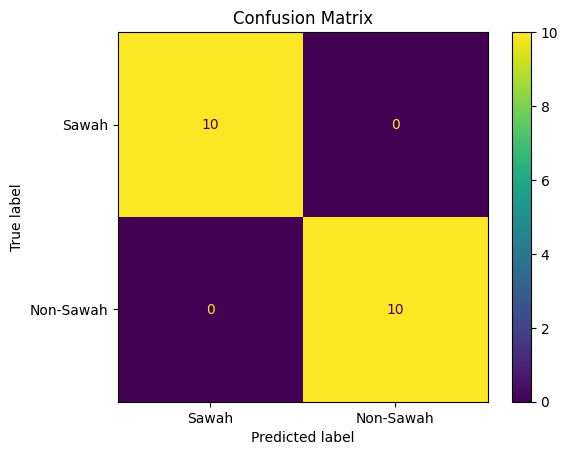

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["sawah", "non_sawah"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Sawah", "Non-Sawah"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#  Menyimpan Dataset

df.to_csv(
    "materi/dataset_sawah_nonsawah.csv",
    index=False
)

print("Dataset tersimpan.")

Dataset tersimpan.


## 15. Membaca Rester untuk Klasifikasi Seluruh Wilayah

Membaca citra raster Sentinel-2A secara keseluruhan, bukan hanya pada lokasi sampel. Raster yang digunakan memiliki ukuran 84 × 225 piksel, sehingga terdapat 18.900 piksel yang akan diklasifikasikan.

In [28]:
import rasterio

tif_path = "materi/Sentinel2_kedungpring_sampel.tif"

src = rasterio.open(tif_path)

print("Band:", src.descriptions)
print("Ukuran:", src.width, "x", src.height)
print("CRS:", src.crs)

Band: ('B02', 'B03', 'B04', 'B08', 'B11')
Ukuran: 84 x 225
CRS: EPSG:32749


## 16. Mengubah Rester menjadi Data Pixel

- 5 = jumlah band
- 225 = tinggi raster
- 84 = lebar raster

Terdapat 18.900 piksel yang akan diklasifikasikan

In [29]:
import numpy as np

data = src.read()

print("Shape:", data.shape)

Shape: (5, 225, 84)


In [30]:
bands, height, width = data.shape

pixels = data.reshape(bands, -1).T

print("Jumlah piksel:", pixels.shape[0])

Jumlah piksel: 18900


In [31]:
B02 = pixels[:, 0]
B03 = pixels[:, 1]
B04 = pixels[:, 2]
B08 = pixels[:, 3]
B11 = pixels[:, 4]

NDVI = (B08 - B04) / (B08 + B04 + 1e-10)

NDWI = (B03 - B08) / (B03 + B08 + 1e-10)

In [32]:
X_raster = np.column_stack([
    B02,
    B03,
    B04,
    B08,
    B11,
    NDVI,
    NDWI
])

print(X_raster.shape)

(18900, 7)


In [ ]:
# Mengecek Pixel Valid

nodata = src.nodata

valid_mask = np.all(
    pixels != nodata,
    axis=1
)

print("Total piksel :", len(pixels))
print("Piksel valid :", valid_mask.sum())
print("Piksel NoData:", (~valid_mask).sum())

Total piksel : 18900
Piksel valid : 18900
Piksel NoData: 0


## 18. Melakukan Klasifikasi Seluruh Pixel

Menggunakan model Random Forest yang sebelumnya sudah dilatih untuk memprediksi seluruh piksel raster.

Dari 18.900 piksel:

- 12.445 piksel diklasifikasikan sebagai sawah.
- 6.455 piksel diklasifikasikan sebagai non-sawah.

Jika dihitung persentasenya:

- Sawah ≈ 65,85%
- Non-sawah ≈ 34,15%

Jadi wilayah raster yang diproses didominasi oleh kelas sawah.

In [35]:
prediksi = np.full(
    len(pixels),
    "",
    dtype="<U20"
)

prediksi[valid_mask] = model.predict(
    X_raster[valid_mask]
)

print("Hasil prediksi:")
print(np.unique(prediksi, return_counts=True))

c:\Users\PC\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Hasil prediksi:
(array(['non_sawah', 'sawah'], dtype='<U20'), array([ 6455, 12445]))


## 19. Mengubah Label Menjadi Nilai Kelas

Kelas dibuat menjadi : 

- 0 = NoData
- 1 = Sawah
- 2 = Non-Sawah

In [36]:
hasil_kelas = np.zeros(
    len(pixels),
    dtype=np.uint8
)

hasil_kelas[
    valid_mask & (prediksi == "sawah")
] = 1

hasil_kelas[
    valid_mask & (prediksi == "non_sawah")
] = 2

print("Jumlah Sawah:", np.sum(hasil_kelas == 1))
print("Jumlah Non-Sawah:", np.sum(hasil_kelas == 2))
print("Jumlah NoData:", np.sum(hasil_kelas == 0))

Jumlah Sawah: 12445
Jumlah Non-Sawah: 6455
Jumlah NoData: 0


In [ ]:
# Menyimpan hasil klasifikasi

output_class = "materi/hasil_klasifikasi_sawah.tif"

profile = src.profile.copy()

profile.update(
    dtype=rasterio.uint8,
    count=1,
    nodata=0
)

with rasterio.open(
    output_class,
    "w",
    **profile
) as dst:

    dst.write(hasil_kelas.reshape(height, width), 1)

print("Berhasil disimpan:")
print(output_class)

Berhasil disimpan:
materi/hasil_klasifikasi_sawah.tif


## 20. Hasil Implementasi Citra di QGIS

- Citra Sampel Sawah

![alt text](sampel_sawah.png)

- Citra Sampel Non-Sawah

![alt text](sampel_snonsawah.png)

- Citra Sentinel2

![alt text](sentinel2.png)

- Citra hasil klasifikasi

![alt text](hasil_klasifikasi.png)
![alt text](hasil_klasifikasi2.png)


